# **Лабораторна робота №1 “Зменшення розмірності даних”**

<p>Виконала студентка ІІ-го курсу</p>
<p>Басовська Марія, групи КН-43</p>

---

<font size="5">**Мета**</font>

Ознайомитися з основами **зменшення розмірності даних (dimensionality reduction)** на прикладі зображень рукописних цифр із набору **MNIST**. Навчитись виконувати метод головних компонент (PCA), інтерпретувати отримані результати, оцінювати втрату інформації після проєкції та реконструкції зображень.

---

<font size="5">**Інструменти**</font>

Python: pandas, numpy, scikit-learn (PCA), matplotlib, plotly; Jupyter Notebook

---

<font size="5">**Хід роботи**</font>

<font size="4">**1.Викачати та підготувати дані**</font>

Працюємо з датасетом MNIST — це 70 000 картинок рукописних цифр (0–9). Кожне зображення 28х28 розміром, і представлено у вигляді вектора з 784 чисел (тобто 28*28=784). Виведемо форму матриці X і кількість унікальних міток у У. Отримали матрицю ознак X розміром (70000х784) і вектор міток y довжиною 70000. Мітка класу відповідає цифрі, зображеній на картинці. Тобто набір даних має високу розмірність, що ускладнює аналіз і візуалізацію. Саме для цього ми застосуємо методи зменшення розмірності в наступних кроках.

Форма X: (70000, 784)
Форма y: (70000,)
Кількість унікальних міток: 10
Унікальні мітки: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


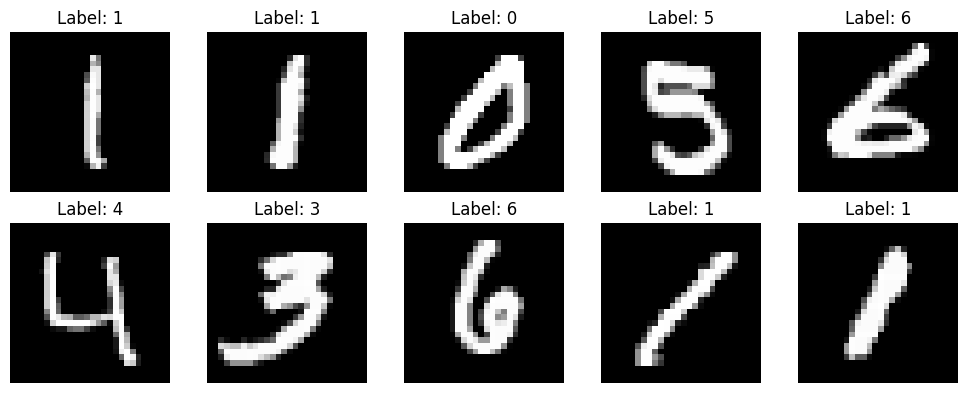

In [1]:
#1. Завантаження MNIST
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target

#2. Форма матриці X та унікальні мітки
print("Форма X:", X.shape)
print("Форма y:", y.shape)

print("Кількість унікальних міток:", len(np.unique(y)))
print("Унікальні мітки:", np.unique(y))

#3. Візуалізація 10 випадкових зображень
indices = np.random.choice(len(X), 10, replace=False)

plt.figure(figsize=(10, 4))

for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

<font size="4">**2. Реалізувати метод головних компонент (PCA)**</font>

<p>PCA — це метод, мета якого зменшити кількість вимірів у даних, і при цьому зберегти максимум інформації. Використавши його, ми зменшимо 784 виміри до 3, тобто кожну цифру описуватимуть лише 3 числа. </p>
<p>У висновку, PCA дозволив суттєво зменшити розмірність даних. Перші три компоненти пояснюють лише частину загальної дисперсії, що означає часткову втрату інформації.</p>

In [2]:
from sklearn.decomposition import PCA

# 1. Нормалізуємо дані
X_normalized = X / 255.0

# 2. Створюємо PCA з 3 компонентами
pca = PCA(n_components=3)

# 3. Навчаємо PCA та отримуємо матрицю проєкцій
X_pca = pca.fit_transform(X_normalized)

# 4. Виведення результатів
print("Розмір X_pca:", X_pca.shape)
print("Відсоток поясненої дисперсії для кожної компоненти:")
print(pca.explained_variance_ratio_)
print("Сумарний відсоток для 3 компонент:", sum(pca.explained_variance_ratio_))

Розмір X_pca: (70000, 3)
Відсоток поясненої дисперсії для кожної компоненти:
[0.09746116 0.07155445 0.06149531]
Сумарний відсоток для 3 компонент: 0.23051091490096487


<font size="4">**3. Візуалізувати дані у просторі перших трьох компонент**</font>

Було побудовано тривимірний графік у просторі перших трьох головних компонент (PC1, PC2, PC3). Точки були зафарбовані відповідно до класу цифри. Візуалізація дозволила подивилися, як цифри розташовані в новому 3D-просторі. Видно, що цифри одного класу формують кластери, а деякі цифри частково перекриваються. Тобто так, PCA дозволяє частково розділити класи у просторі меншої розмірності, проте повністю відокремити їх метод не здатен, адже не враховує мітки класів.

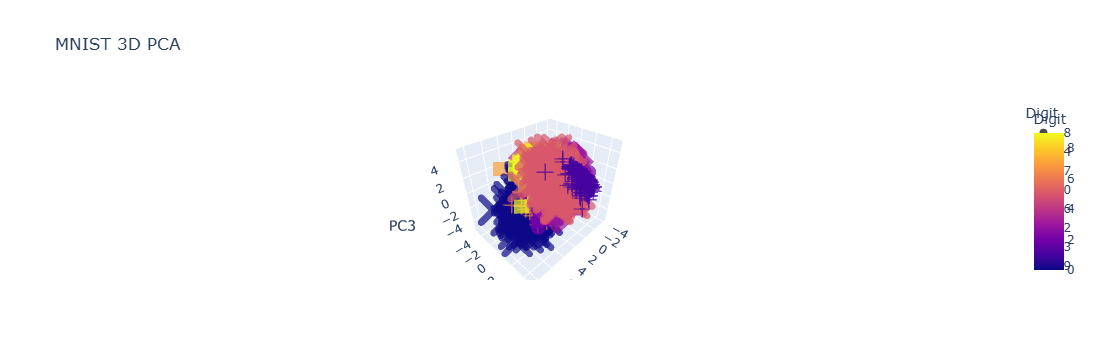

In [3]:
np.random.seed(42)
sample_indices = np.random.choice(X_pca.shape[0], 2000, replace=False)

X_sample = X_pca[sample_indices]
y_sample = y[sample_indices].astype(int)

import plotly.express as px
import pandas as pd

df_pca = pd.DataFrame({
    'PC1': X_sample[:, 0],
    'PC2': X_sample[:, 1],
    'PC3': X_sample[:, 2],
    'Digit': y_sample
})

fig = px.scatter_3d(
    df_pca, x='PC1', y='PC2', z='PC3',
    color='Digit', symbol='Digit',
    opacity=0.7,
    title="MNIST 3D PCA"
)

fig.show()

<font size="4">**4. Реконструкція зображень після зменшення розмірності**</font>

За допомогою методу inverse_transform() було виконано відновлення зображень із простору трьох головних компонент назад у початковий 784-вимірний простір. Після цього порівняємо оригінал та реконструкцію зображень, і бачимо суттєву втрату даних: зображення стали розмитими. Точніше, основна форми цифри збереглась, але були втрачені дрібні деталі. Оскільки кожне зображення представлено у вигляді вектору з чисел, втрата числових даних, навіть найдрібніших, суттєво впливає на те, як зображення рендеряться.   

Форма реконструйованих даних: (70000, 784)


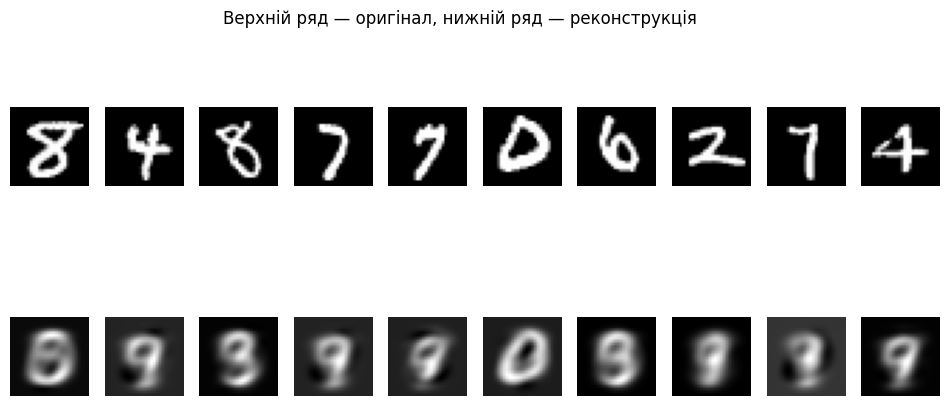

In [5]:
X_reconstructed = pca.inverse_transform(X_pca)

print("Форма реконструйованих даних:", X_reconstructed.shape)

np.random.seed(42)
indices = np.random.choice(X.shape[0], 10, replace=False)

plt.figure(figsize=(12, 5))

for i, idx in enumerate(indices):
    
    plt.subplot(2, 10, i + 1)
    plt.imshow(X_normalized[idx].reshape(28, 28), cmap='gray')
    plt.axis('off')
    
    plt.subplot(2, 10, i + 11)
    plt.imshow(X_reconstructed[idx].reshape(28, 28), cmap='gray')
    plt.axis('off')

plt.suptitle("Верхній ряд — оригінал, нижній ряд — реконструкція")
plt.show()

<font size="4">**5. Проаналізувати залежність між помилкою реконструкції та кількістю компонент**</font>

Наступним кроком оцінимо наскільки відрізняється зображення після РСА та до нього. Для цього обчислимо середньоквадратичну помилку реконструкції (MSE) для різних значень кількості компонент k. Для наглядності побудуємо графіки MSE(k) та сумарної дисперсії залежно від k. Бачимо, що якщо брати більше компонент, то помилка зменшується і навпаки, якщо брати мало компонент, то помилка велика, а після певного значення k покращення стає незначним.

Обробка k = 1
Обробка k = 5
Обробка k = 10
Обробка k = 20
Обробка k = 50
Обробка k = 100
Обробка k = 200


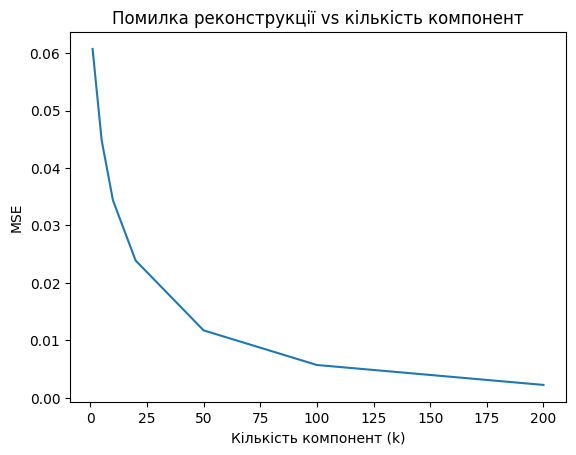

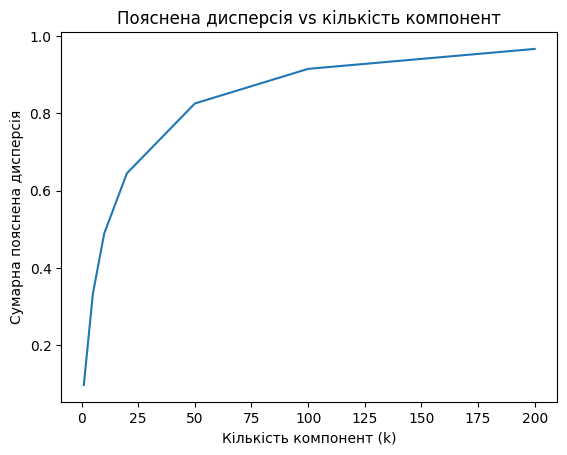

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

X_data = X_normalized

k_values = [1, 5, 10, 20, 50, 100, 200]

mse_values = []
explained_variances = []

for k in k_values:
    print(f"Обробка k = {k}")
    
    pca = PCA(n_components=k)
    X_pca_k = pca.fit_transform(X_data)
    X_reconstructed_k = pca.inverse_transform(X_pca_k)
    
    mse = mean_squared_error(X_data, X_reconstructed_k)
    
    mse_values.append(mse)
    explained_variances.append(np.sum(pca.explained_variance_ratio_))

plt.figure()
plt.plot(k_values, mse_values)
plt.xlabel("Кількість компонент (k)")
plt.ylabel("MSE")
plt.title("Помилка реконструкції vs кількість компонент")
plt.show()

plt.figure()
plt.plot(k_values, explained_variances)
plt.xlabel("Кількість компонент (k)")
plt.ylabel("Сумарна пояснена дисперсія")
plt.title("Пояснена дисперсія vs кількість компонент")
plt.show()

---

<font size="5">**Висновок**</font>

<p>У ході роботи було досліджено метод головних компонент для зменшення розмірності зображень рукописних цифр. Було встановлено, що PCA дозволяє суттєво зменшити розмірність даних; перші компоненти зберігають основну варіативність даних; зі зменшенням розмірності зростає втрата інформації; існує компроміс між компактністю представлення та точністю реконструкції. </p>
<p>Метод PCA є ефективним інструментом попередньої обробки даних та візуалізації високовимірних просторів.</p>